# Optimizing Stock Trading Strategy with K-Means Clustering

Big Data Analytics mini project — Department of Computer Engineering,
Atharva College of Engineering, University of Mumbai.

Companies are grouped by the **pattern of their daily price movement**
(`Close - Open`) rather than by sector label, using K-Means clustering.

Data: 28 large-cap US-listed companies, 1 Jan 2015 - 31 Dec 2017, 755 trading days.

## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict

from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Define the company universe

In [2]:
companies_dict = OrderedDict({
    'Amazon':            'AMZN',
    'Apple':             'AAPL',
    'CVS Health':        'CVS',
    'Northrop Grumman':  'NOC',
    'Boeing':            'BA',
    'Lockheed Martin':   'LMT',
    'McDonalds':         'MCD',
    'Intel':             'INTC',
    'Paccar':            'PCAR',
    'IBM':               'IBM',
    'Texas Instruments': 'TXN',
    'MasterCard':        'MA',
    'Microsoft':         'MSFT',
    'General Electrics': 'GE',
    'Gen Digital':       'GEN',
    'American Express':  'AXP',
    'Pepsi':             'PEP',
    'Coca Cola':         'KO',
    'Johnson & Johnson': 'JNJ',
    'Toyota':            'TM',
    'Honda':             'HMC',
    'Mitsubishi UFJ':    'MUFG',
    'Sony':              'SONY',
    'Exxon':             'XOM',
    'Chevron':           'CVX',
    'Valero Energy':     'VLO',
    'Ford':              'F',
    'Bank of America':   'BAC'})

tickers = list(companies_dict.values())
print(f'{len(tickers)} companies')

28 companies


## 3. Load the dataset

The original project used `pandas_datareader` with `data_source='yahoo'`.
That endpoint was retired by Yahoo and the reader has since been removed from
pandas-datareader, so this notebook reads the committed CSV snapshot instead
and falls back to `yfinance` if the file is missing.

In [3]:
START, END = '2015-01-01', '2017-12-31'
CSV_PATH = 'data/stock_data_2015_2017.csv'
ATTRS = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

try:
    raw = pd.read_csv(CSV_PATH, header=[0, 1], index_col=0, parse_dates=True)
    print(f'Loaded cached snapshot: {CSV_PATH}')
except FileNotFoundError:
    import yfinance as yf
    print('Cache not found - downloading from Yahoo Finance...')
    raw = yf.download(tickers, start=START, end=END,
                      progress=False, auto_adjust=False)
    raw = raw.swaplevel(axis=1).sort_index(axis=1)
    raw = raw.reindex(columns=pd.MultiIndex.from_product([tickers, ATTRS]))
    raw.columns.names = ['Symbols', 'Attributes']
    raw.to_csv(CSV_PATH)

# attribute-major view: df['Open'], df['Close'], ...
df = raw.swaplevel(axis=1).sort_index(axis=1)
print('shape:', raw.shape, ' missing values:', int(raw.isna().sum().sum()))

Loaded cached snapshot: data/stock_data_2015_2017.csv
shape: (755, 168)  missing values: 0


In [4]:
df.head()

Attributes  Adj Close                                                        \
Symbols          AAPL     AMZN        AXP          BA        BAC        CVS   
Date                                                                          
2015-01-02  24.171759  15.4260  78.824417  113.657211  13.979471  68.013908   
2015-01-05  23.490797  15.1095  76.739853  112.870071  13.573365  67.341652   
2015-01-06  23.493013  14.7645  75.104393  111.540627  13.167256  67.391693   
2015-01-07  23.822437  14.9210  76.744675  113.272385  13.229735  68.607536   
2015-01-08  24.737747  15.0230  77.832542  115.275269  13.503078  70.066490   

Attributes                                             ...    Volume           \
Symbols           CVX         F          GE       GEN  ...      MSFT     MUFG   
Date                                                   ...                      
2015-01-02  68.302246  8.242642  102.303185  9.478634  ...  27913900  1809800   
2015-01-05  65.572098  7.920666  100.425323  9.345289  ...  39673900   996000   
2015-01-06  65.541756  7.845535   98.261688  9.200830  ...  36447900  2330400   
2015-01-07  65.487175  8.070921   98.302483  9.286025  ...  29114100  1088100   
2015-01-08  66.985703  8.274840   99.486389  9.456409  ...  29645200  4177100   

Attributes                                                                 \
Symbols         NOC     PCAR      PEP      SONY      TM      TXN      VLO   
Date                                                                        
2015-01-02  2042000  2262000  3545700   6149500  250000  4020100  5897000   
2015-01-05  5765000  4089900  6441000   5415500  240600  5599300  7732700   
2015-01-06  3121100  6294750  6195000  11045500  285600  5468400  8586800   
2015-01-07  2369900  2675400  6526300  12431500  385700  4577100  8825800   
2015-01-08  3466300  3087000  7131600   6482500  498800  6295200  8941700   

Attributes            
Symbols          XOM  
Date                  
2015-01-02  10220400  
2015-01-05  18502400  
2015-01-06  16670700  
2015-01-07  13590700  
2015-01-08  15487500  

[5 rows x 168 columns]

### Attribute reference

| Attribute | Description |
|---|---|
| Open | First traded price of the session |
| High | Highest price during the session |
| Low | Lowest price during the session |
| Close | Last traded price of the session |
| Adj Close | Close adjusted for dividends and splits |
| Volume | Shares exchanged during the session |

## 4. Feature engineering - daily price movement

    movement = Close - Open

One row per company, one column per trading day.

In [5]:
stock_open  = np.array(df['Open'][tickers]).T
stock_close = np.array(df['Close'][tickers]).T

movements = stock_close - stock_open
print('movements:', movements.shape)

movements: (28, 755)


In [6]:
sum_of_movement = np.sum(movements, axis=1)

for i, ticker in enumerate(tickers):
    print(f'{ticker:6s} net movement: {sum_of_movement[i]:8.2f}')

AMZN   net movement:    -4.14
AAPL   net movement:     4.17
CVS    net movement:   -20.07
NOC    net movement:    75.39
BA     net movement:   102.72
LMT    net movement:    60.24
MCD    net movement:    51.34
INTC   net movement:    19.86
PCAR   net movement:    12.87
IBM    net movement:    14.95
TXN    net movement:    29.14
MA     net movement:    24.59
MSFT   net movement:    28.76
GE     net movement:    23.20
GEN    net movement:    13.23
AXP    net movement:     7.21
PEP    net movement:    38.08
KO     net movement:    12.16
JNJ    net movement:    31.66
TM     net movement:   -17.31
HMC    net movement:    -8.06
MUFG   net movement:     2.20
SONY   net movement:    -0.05
XOM    net movement:     9.90
CVX    net movement:    26.57
VLO    net movement:    29.46
F      net movement:    -5.55
BAC    net movement:    -3.48


## 5. Exploratory data analysis

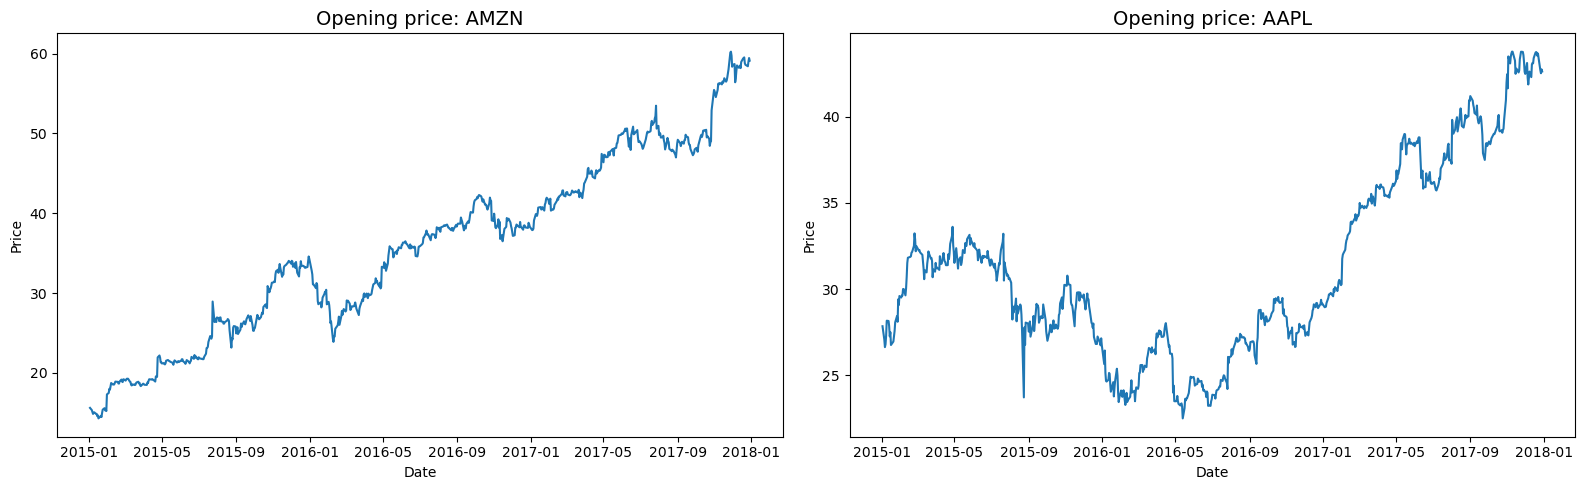

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for a, t in zip(ax, ['AMZN', 'AAPL']):
    a.plot(df['Open'][t])
    a.set_title(f'Opening price: {t}', fontsize=14)
    a.set_xlabel('Date'); a.set_ylabel('Price')
plt.tight_layout(); plt.show()

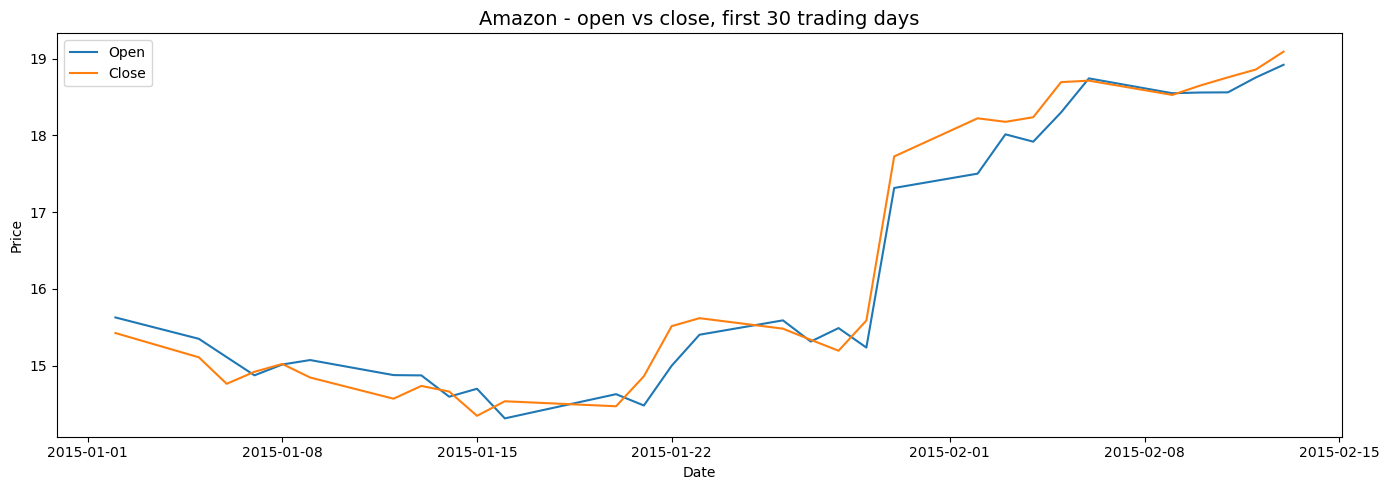

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df.iloc[:30]['Open']['AMZN'],  label='Open')
plt.plot(df.iloc[:30]['Close']['AMZN'], label='Close')
plt.title('Amazon - open vs close, first 30 trading days', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Price'); plt.legend()
plt.tight_layout(); plt.show()

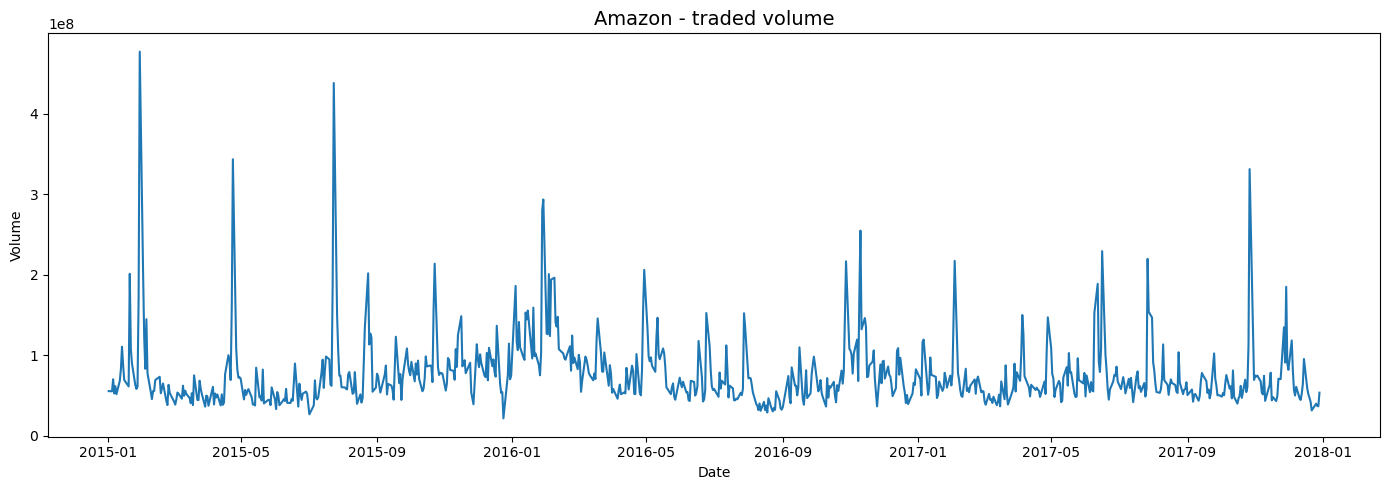

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df['Volume']['AMZN'])
plt.title('Amazon - traded volume', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Volume')
plt.tight_layout(); plt.show()

Plotted on a shared vertical axis, the movement of an expensive stock dwarfs
that of a cheaper one. This is what motivates the normalisation step.

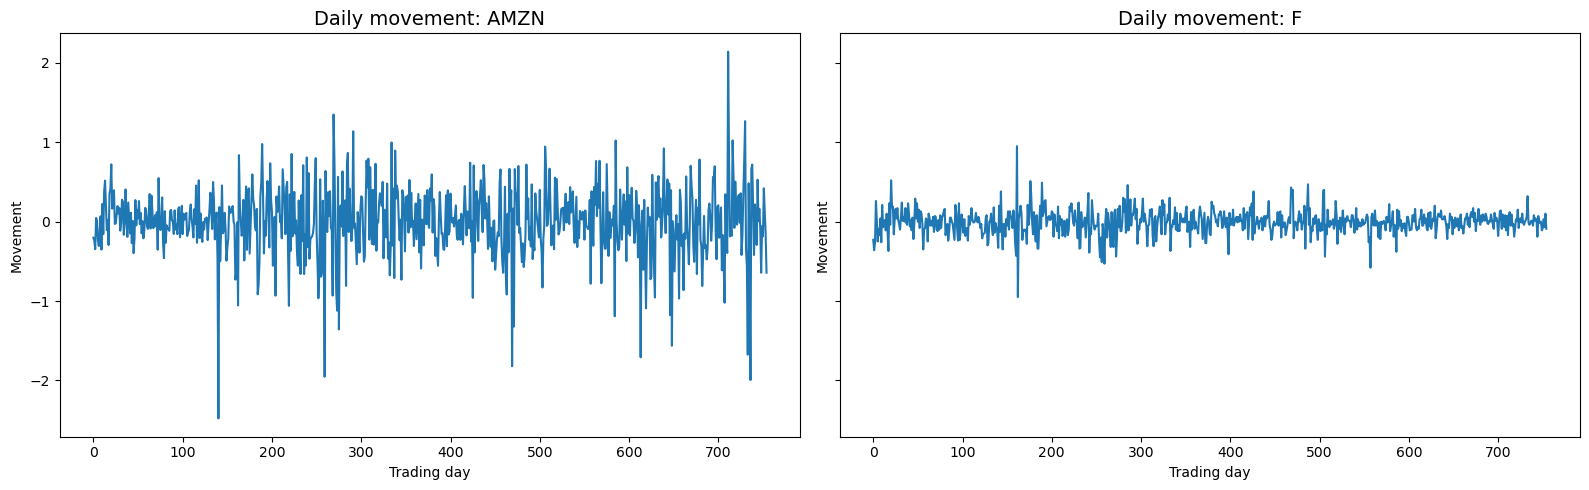

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for a, (t, i) in zip(ax, [('AMZN', 0), ('F', 26)]):
    a.plot(movements[i])
    a.set_title(f'Daily movement: {t}', fontsize=14)
    a.set_xlabel('Trading day'); a.set_ylabel('Movement')
plt.tight_layout(); plt.show()

## 6. Normalisation

`Normalizer` scales each **row** to unit L2 norm, so every company's movement
vector has length 1. Clustering then compares the *shape and timing* of the
movement pattern rather than its magnitude - effectively cosine similarity.

In [11]:
normalizer = Normalizer()
norm_movements = normalizer.fit_transform(movements)

print('min :', norm_movements.min())
print('max :', norm_movements.max())
print('mean:', norm_movements.mean())

min : -0.2599107268296998
max : 0.27354163152344924
mean: 0.0009828955930977958


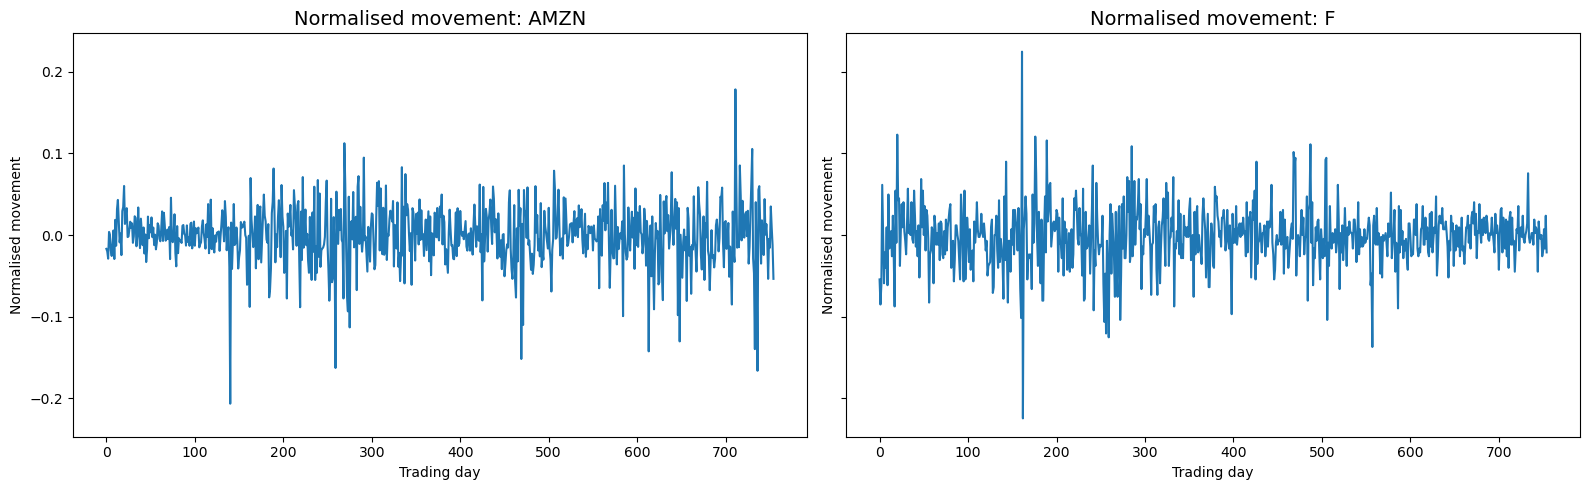

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for a, (t, i) in zip(ax, [('AMZN', 0), ('F', 26)]):
    a.plot(norm_movements[i])
    a.set_title(f'Normalised movement: {t}', fontsize=14)
    a.set_xlabel('Trading day'); a.set_ylabel('Normalised movement')
plt.tight_layout(); plt.show()

## 7. K-Means clustering (without dimensionality reduction)

K = 10 over 28 companies gives tight groups of close substitutes, and lets a
company with no counterpart be isolated rather than forced into an unrelated
group.

In [13]:
kmeans = KMeans(n_clusters=10, max_iter=1000,
                random_state=RANDOM_STATE, n_init=10)
pipeline = make_pipeline(Normalizer(), kmeans)
pipeline.fit(movements)

labels = pipeline.predict(movements)
print('inertia (WCSS):', kmeans.inertia_)

inertia (WCSS): 9.380630200812188


In [14]:
df1 = pd.DataFrame({'labels': labels,
                    'companies': list(companies_dict.keys())}
                   ).sort_values(by=['labels'], axis=0)
df1

,labels,companies
2,0,CVS Health
1,1,Apple
7,1,Intel
10,1,Texas Instruments
24,2,Chevron
23,2,Exxon
3,3,Northrop Grumman
4,3,Boeing
5,3,Lockheed Martin
13,4,General Electrics


In [15]:
for label, group in df1.groupby('labels'):
    print(f'Cluster {label} ({len(group)}): ' + ', '.join(group.companies))

Cluster 0 (1): CVS Health
Cluster 1 (3): Apple, Intel, Texas Instruments
Cluster 2 (2): Chevron, Exxon
Cluster 3 (3): Northrop Grumman, Boeing, Lockheed Martin
Cluster 4 (8): General Electrics, Sony, Mitsubishi UFJ, Honda, Toyota, American Express, Bank of America, Ford
Cluster 5 (1): McDonalds
Cluster 6 (4): Microsoft, MasterCard, Gen Digital, Amazon
Cluster 7 (1): Valero Energy
Cluster 8 (2): IBM, Paccar
Cluster 9 (3): Pepsi, Coca Cola, Johnson & Johnson


## 8. K-Means clustering with PCA

PCA reduces each 755-dimensional movement vector to 2 components, which makes
the clusters plottable.

In [16]:
pca    = PCA(n_components=2, random_state=RANDOM_STATE)
kmeans_pca = KMeans(n_clusters=10, max_iter=1000,
                    random_state=RANDOM_STATE, n_init=10)

pipeline_pca = make_pipeline(Normalizer(), pca, kmeans_pca)
pipeline_pca.fit(movements)
labels_pca = pipeline_pca.predict(movements)

print('explained variance ratio:', pca.explained_variance_ratio_)
print('total variance retained :', pca.explained_variance_ratio_.sum())
print('inertia (WCSS)          :', kmeans_pca.inertia_)

explained variance ratio: [0.10975119 0.08840583]
total variance retained : 0.19815701827600496
inertia (WCSS)          : 0.10240269464747553


In [17]:
df2 = pd.DataFrame({'labels': labels_pca,
                    'companies': list(companies_dict.keys())}
                   ).sort_values(by=['labels'], axis=0)
df2

,labels,companies
1,0,Apple
14,0,Gen Digital
11,0,MasterCard
10,0,Texas Instruments
2,1,CVS Health
4,1,Boeing
27,2,Bank of America
15,2,American Express
26,2,Ford
21,2,Mitsubishi UFJ


## 9. Cluster map

The mesh is predicted with the **same PCA transform that the model was fitted
on**, taken from the pipeline, so the decision regions match the model exactly.

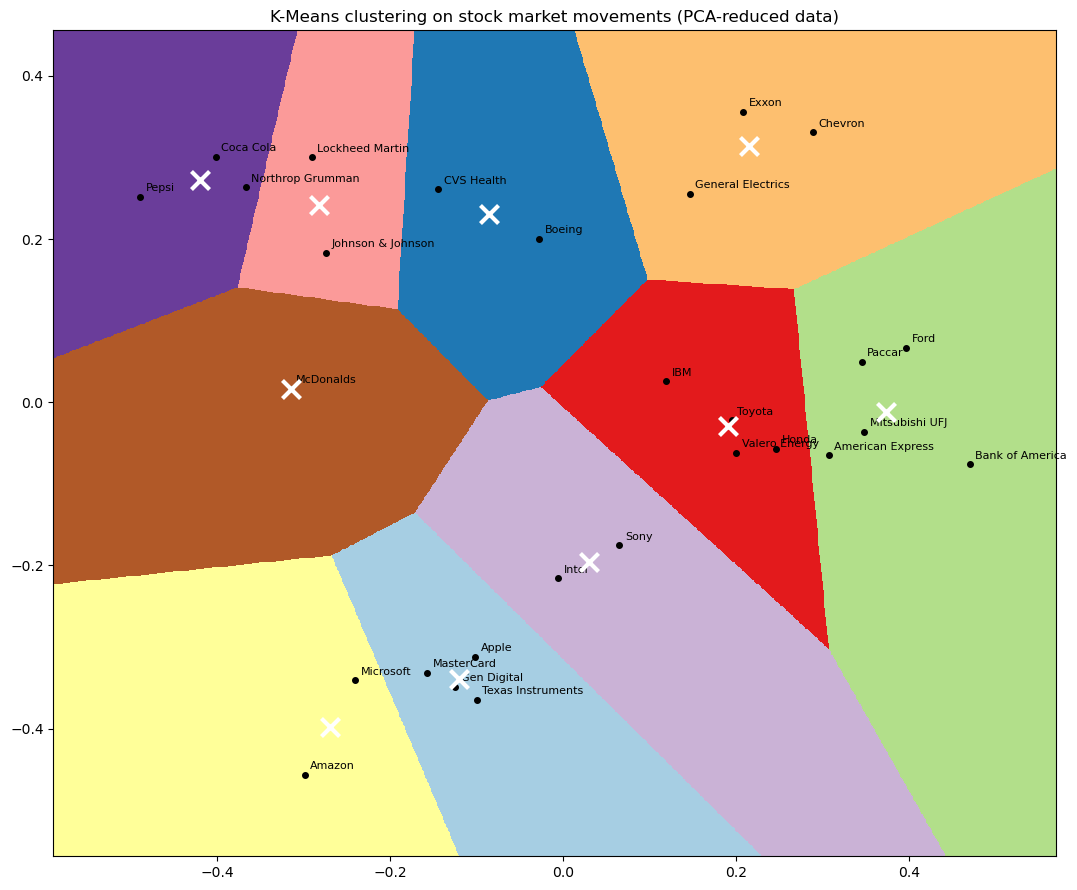

In [18]:
reduced = pipeline_pca.named_steps['pca'].transform(
    pipeline_pca.named_steps['normalizer'].transform(movements))

h = 0.001
x_min, x_max = reduced[:, 0].min() - 0.1, reduced[:, 0].max() + 0.1
y_min, y_max = reduced[:, 1].min() - 0.1, reduced[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = kmeans_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(11, 9))
plt.imshow(Z, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Paired, aspect='auto', origin='lower')
plt.plot(reduced[:, 0], reduced[:, 1], 'k.', markersize=8)

centroids = kmeans_pca.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x',
            s=169, linewidths=3, color='w', zorder=10)

for i, name in enumerate(companies_dict.keys()):
    plt.annotate(name, (reduced[i, 0], reduced[i, 1]),
                 fontsize=8, xytext=(4, 4), textcoords='offset points')

plt.title('K-Means clustering on stock market movements (PCA-reduced data)')
plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.tight_layout(); plt.show()

## 10. Results

Clustering the full 755-dimensional movement vectors recovers recognisable
economic groups, although the algorithm was given nothing but the daily
difference between close and open:

- **Northrop Grumman, Boeing, Lockheed Martin** - aerospace and defence, recovered exactly
- **Exxon, Chevron** - integrated oil, recovered exactly
- **Pepsi, Coca Cola, Johnson & Johnson** - consumer staples and healthcare
- **Apple, Intel, Texas Instruments** - technology hardware and semiconductors
- **Microsoft, MasterCard, Gen Digital, Amazon** - growth technology and payments

Two components retain only about 20% of the variance, so the PCA pipeline
breaks up some of these groups. It is useful for visualisation, while the
full-dimensional clustering is the more reliable partition.

The practical consequence: holding Boeing, Lockheed Martin and Northrop Grumman
together is not diversification, and the price data alone makes that visible.